# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**

**Dr Luis Eduardo Falcón Morales**

**Tecnológico de Monterrey**
### **Actividad Individual: Pronósticos con Series de Tiempo**


#### **Nombre:** Ramón Orlando Cabrera Cabrera
#### **Matrícula:** A01796634

Modelos para predicción de un problema de serie de tiempo:

* **1. Modelo ingenuo**
* **2. Modelo ARIMA**
* **3. Modelo Prophet**
* **4. Modelo LSTM**


NOTA: Recuerda que cada modelo puede llegar a tener una gran cantidad de hiperparámetros y tipo de ajsutes, por lo que siempre inicia con un modelo sencillo y de ahí buscar mejorar su resultado. Esto para no desgastarte desde un inicio buscando la mayor cantidad de ajustes e hiperparámetros.

# **A - Introducción**

In [35]:
# Agrega aquí todas las librerías y paquetes adicionales que requieras.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt






# **Ejercicio 1**

* **1a. De la página de Google-Trends generar y descargar los datos con períodos mensuales que se obtienen con el "Término de búsqueda" de "chocolate", del país "Estados Unidos", de los últimos 20 años (del 1 de mayo del 2006 al 30 de abril del 2026) y con las opciones de "todas las categorías" y "búsqueda de web". De manera predeterminada se generan datos mensuales.**

* **1b. Cargar los datos en un DataFrame de Pandas llamado "dfp" y con los nombres"ds" y "y" para las columnas de fechas y porcentajes de interés de búsqueda, respectivamente. Las fechas ajustarlas al formato YYYY-MM-DD, con días de fin de mes. Este formato es el que se requiere para el modelo Prophet.**

* **1c. A partir del DataFrame "dfp", genera ahora el DataFrame que llamaremos "dfr" para el resto de los modelos. El formato en "dfr" requerido para el resto de los modelos debe tener la primera columna de fechas de "dfp" ahora como índice del DataFrame "dfr". Además, el índice de fechas debe tener una frecuencia mensual al final del mes.**



https://trends.google.es/trends/



In [36]:
# Ejercicios 1a y 1b.

# ************* Inlcuye aquí tu código:*****************************


url = "https://raw.githubusercontent.com/A01796634/Inteligencia-artificial-y-aprendizaje-autom-tico/main/time_series_US_20060101-0000_20260622-0709.csv"

# Leer archivo, saltando la primera fila problemática
dfp = pd.read_csv(
    url,
    header=None,
    names=["ds", "y"],
    skiprows=1
)

# Convertir fechas al formato requerido por Prophet
dfp["ds"] = pd.to_datetime(dfp["ds"], format="%Y-%m-%d")

# Ajustar las fechas al final de cada mes
dfp["ds"] = dfp["ds"].dt.to_period("M").dt.to_timestamp("M")

# Convertir interés de búsqueda a número
dfp["y"] = pd.to_numeric(dfp["y"], errors="coerce")

# Eliminar filas vacías
dfp = dfp.dropna()

# Filtrar hasta el 30 de abril de 2026
dfp = dfp[dfp["ds"] <= "2026-04-30"]

# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por el modelo Prophet de Meta:")
print("Dimensión del DataFrame:", dfp.shape)
print(dfp.head())
print(dfp.tail())


Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por el modelo Prophet de Meta:
Dimensión del DataFrame: (244, 2)
          ds   y
0 2006-01-31  37
1 2006-02-28  44
2 2006-03-31  30
3 2006-04-30  31
4 2006-05-31  31
            ds    y
239 2025-12-31  100
240 2026-01-31   73
241 2026-02-28   77
242 2026-03-31   65
243 2026-04-30   80


**Análisis:** La serie de tiempo sobre el interés de búsqueda del término “Chocolate” en Estados Unidos fue construida correctamente a partir de datos mensuales de Google Trends, abarcando el período comprendido entre enero de 2006 y abril de 2026. Después del proceso de depuración y filtrado, el conjunto de datos quedó conformado por 244 observaciones y dos variables: ds, correspondiente a las fechas, y y, que representa el índice de interés de búsqueda.

In [37]:
# Ejercicio 1c.

# ************* Inlcuye aquí tu código:*****************************

dfr = dfp.copy()

# Columna de fechas como índice
dfr.set_index("ds", inplace=True)

# Frecuencia mensual al final del mes
dfr = dfr.asfreq("ME")



# *********** Aquí termina la sección de agregar código *************

print("Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.")
print("Formato requerido por los modelos restantes:")
print(dfr.shape)
print(dfr.head())
print(dfr.index)


Serie de tiempo sobre el interés de búsqueda de Chocolate en EEUU en Google.
Formato requerido por los modelos restantes:
(244, 1)
             y
ds            
2006-01-31  37
2006-02-28  44
2006-03-31  30
2006-04-30  31
2006-05-31  31
DatetimeIndex(['2006-01-31', '2006-02-28', '2006-03-31', '2006-04-30',
               '2006-05-31', '2006-06-30', '2006-07-31', '2006-08-31',
               '2006-09-30', '2006-10-31',
               ...
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31', '2026-01-31', '2026-02-28',
               '2026-03-31', '2026-04-30'],
              dtype='datetime64[ns]', name='ds', length=244, freq='ME')


**Análisis:** El DataFrame dfr fue generado a partir del conjunto de datos original, quedando conformado por 244 observaciones mensuales y una única variable de interés (y). La columna de fechas (ds) fue establecida como índice del DataFrame, obteniéndose un índice de tipo DatetimeIndex con frecuencia mensual al final de cada mes (ME), tal como requieren los modelos de series de tiempo distintos de Prophet.

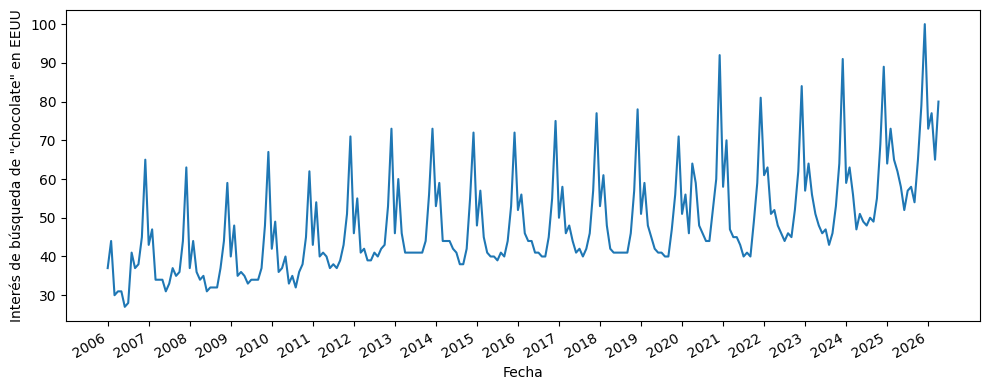

In [38]:
# Veamos el comportamiento de la serie de tiempo, en particular usemos dfp:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 4)

fig, ax = plt.subplots()

ax.plot(dfp['y'])
ax.set_xlabel('Fecha')
ax.set_ylabel('Interés de búsqueda de "chocolate" en EEUU')

xticks_locs = np.arange(0, len(dfp), 12) # lista: 0,12,24,36,...,240... cada 12 meses se agregará una etiqueta del año.
xticks_labels = dfp['ds'].dt.year.iloc[xticks_locs]

plt.xticks(xticks_locs, xticks_labels)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Análisis:** La serie de tiempo presenta una tendencia creciente en el interés de búsqueda del término “chocolate” en Estados Unidos durante el período 2006-2026. Además, se observan patrones estacionales recurrentes, con picos de búsqueda que se repiten aproximadamente cada año.

In [39]:
# Partición:
# Particionamos en conjunto de Prueba, Validación y Prueba de acuerdo a
# datos de una serie de tiempo y considerando el caso Prophet y el resto
# de los modelos.
# Hacemos esta diferenciación solo por fines prácticos de la actividad y
# en su momento utilizar los conjuntos respectivos en cada caso de manera
# más sencilla en la actividad.

# Para el modelo Prophet:
testP = dfp[-12:]      # El último año para prueba.
valP = dfp[-24:-12]    # El penúltimo año para validación.
trainP = dfp[:-24]     # El resto de los primeros datos para entrenamiento.

# Para el resto de los modelos:
testR = dfr[-12:]
valR = dfr[-24:-12]
trainR = dfr[:-24]


* **El objetivo de esta actividad es encontrar un modelo que pueda predecir el interés de búsqueda de la palabra "chocolate" en el navegador de Google para el próximo año. Para ello, buscaremos el modelo entrenando y validando con los conjuntos Train y Val, midiendo el desempeño con el error MAE. Con el mejor modelo encontrado obtendremos el desempeño final con el conjnuto de Prueba (Test).**

# **B - Modelo ingenuo**

# **Ejercicio - 2**

* **Iniciemos con el modelo base o ingenuo (naive/baseline).**

* **2a. En esta actividad usaremos la métrica del Error Absoluto Medio, MAE por sus siglas en inglés, "Mean Absolute Error", para monitorear el desempeño de nuestros modelos. Enuncia ventajas y desventajas de usar MAE en comparación con el error cuadrático medio MSE.**

* **2b. Encontrar e imprimir el valor del desempeño del modelo ingenuo con respecto al error MAE, llamarlo maeNaive. Utiliza el conjunto de entrenamiento trainR y como conjunto de validación valR.**

* **2c. ¿Cómo interpretas el valor MAE obtenido con el modelo ingenuo en el contexto del problema?**

* **2d. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ingenuo, junto con los valores reales.**

**Ejercicio 2a:**

++++++++ Inicia la sección de agregar texto: +++++++++++


De acuerdo con Trevor Hastie, el Error Absoluto Medio (MAE) es una métrica que cuantifica el promedio de las diferencias absolutas entre los valores observados y los valores predichos, proporcionando una medida fácilmente interpretable del error de predicción. Entre sus principales ventajas se encuentran su simplicidad de interpretación y su menor sensibilidad a valores atípicos en comparación con el Error Cuadrático Medio (MSE), ya que no eleva al cuadrado las desviaciones. Sin embargo, el MSE penaliza con mayor severidad los errores grandes, lo que resulta útil cuando se desea dar mayor importancia a predicciones con desviaciones significativas. Por tanto, mientras que el MAE ofrece una medida más robusta y fácil de interpretar, el MSE es más adecuado cuando se requiere enfatizar la reducción de errores extremos (Hastie et al., 2009).


***Referencias***

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7


++++++++ Termina la sección de agregar texto. +++++++++++

In [40]:
# Ejercicio 2b:

# ************* Inlcuye aquí tu código:*****************************
# Incluye todas las celdas que consideres adecuadas.


from sklearn.metrics import mean_absolute_error
import numpy as np

y_pred_naive = np.repeat(trainR["y"].iloc[-1], len(valR))

maeNaive = mean_absolute_error(valR["y"], y_pred_naive)



# *********** Aquí termina la sección de agregar código *************


print('\nError-modelo-Naive : MAE: %.3f' % maeNaive)



Error-modelo-Naive : MAE: 13.333


**Ejercicio 2c:**

++++++++ Inicia la sección de agregar texto: +++++++++++


El modelo ingenuo obtuvo un Error Absoluto Medio (MAE) de 13.333, lo que indica que, en promedio, las predicciones realizadas difieren en aproximadamente 13.33 unidades respecto a los valores reales del conjunto de validación. Dado que este modelo utiliza únicamente el último valor observado del conjunto de entrenamiento para generar todas las predicciones, su desempeño sirve como una línea base de referencia para evaluar modelos más avanzados.

En el contexto del problema, un MAE de 13.333 sugiere que existe margen para mejorar la precisión de las predicciones mediante modelos más sofisticados, como ARIMA, Prophet o LSTM. Por tanto, cualquier modelo posterior que logre un MAE inferior a este valor podrá considerarse superior al modelo ingenuo en términos de capacidad predictiva.


++++++++ Termina la sección de agregar texto. +++++++++++

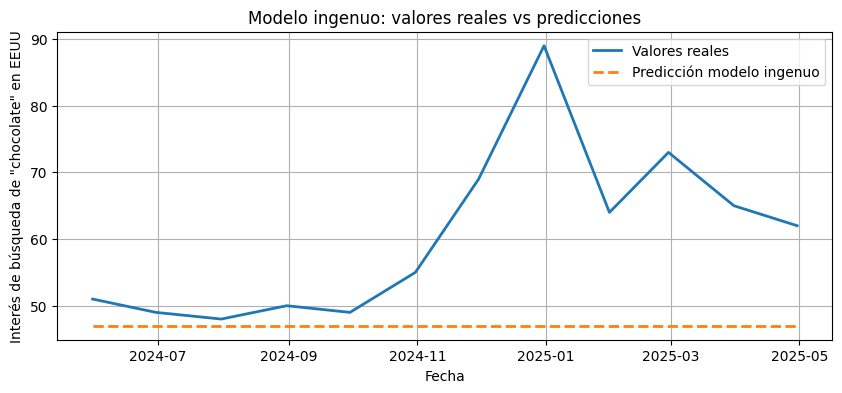

In [41]:
# Ejercicio 2d:

# ************* Inlcuye aquí tu código:*****************************


y_pred_naive = np.repeat(trainR["y"].iloc[-1], len(valR))

# Gráfico
plt.figure(figsize=(10,4))

plt.plot(valR.index,
         valR["y"],
         label="Valores reales",
         linewidth=2)

plt.plot(valR.index,
         y_pred_naive,
         label="Predicción modelo ingenuo",
         linestyle="--",
         linewidth=2)

plt.xlabel("Fecha")
plt.ylabel('Interés de búsqueda de "chocolate" en EEUU')
plt.title("Modelo ingenuo: valores reales vs predicciones")
plt.legend()
plt.grid(True)

plt.show()



# *********** Aquí termina la sección de agregar código *************


**Análisis**

El gráfico muestra que el modelo ingenuo genera una predicción constante basada en el último valor observado del conjunto de entrenamiento, representado por la línea punteada. Por su parte, los valores reales presentan una variación considerable y un incremento significativo durante algunos meses, especialmente a finales de 2024 e inicios de 2025.

# **C - modelo ARIMA**

# **Ejercicio - 3**

* **3a. Aplica el modelo ARIMA con los conjuntos de entrenamiento y validación trainR y valR, usando como métrica el error absoluto medio. Llamar al error maeARIMA.**

* **3b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo ARIMA, junto con los valores reales.**

In [42]:
# Ejercicio 3a - ARIMA

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Entrenar modelo ARIMA
modeloARIMA = ARIMA(trainR["y"], order=(1,1,1))
modeloARIMA_fit = modeloARIMA.fit()

# Predicciones para el conjunto de validación
predARIMA = modeloARIMA_fit.forecast(steps=len(valR))

# Calcular MAE
maeARIMA = mean_absolute_error(valR["y"], predARIMA)




In [43]:
print('\nError-modelo-ARIMA : MAE: %.3f' % maeARIMA)


Error-modelo-ARIMA : MAE: 11.865


**Análisis:**
El modelo ARIMA obtuvo un Error Absoluto Medio (MAE) de 11.865, lo que significa que, en promedio, las predicciones difieren en aproximadamente 11.87 unidades respecto a los valores reales del conjunto de validación. Este resultado representa una mejora con respecto al modelo ingenuo, cuyo MAE fue de 13.333.

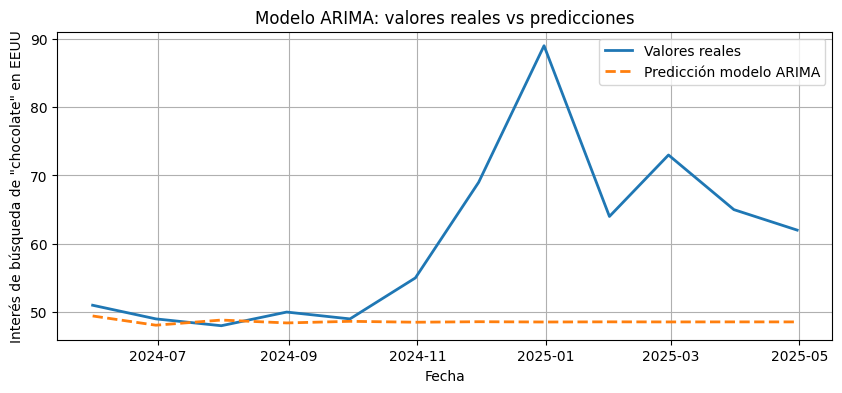

In [44]:
# Ejercicio 3b. ARIMA-gráfica:

# ************* Inlcuye aquí tu código:*****************************


plt.figure(figsize=(10,4))

# Valores reales
plt.plot(valR.index,
         valR["y"],
         label="Valores reales",
         linewidth=2)

# Predicciones del modelo ARIMA
plt.plot(valR.index,
         predARIMA,
         label="Predicción modelo ARIMA",
         linestyle="--",
         linewidth=2)

plt.xlabel("Fecha")
plt.ylabel('Interés de búsqueda de "chocolate" en EEUU')
plt.title("Modelo ARIMA: valores reales vs predicciones")
plt.legend()
plt.grid(True)

plt.show()



# *********** Aquí termina la sección de agregar código *************

**Análisis:**
El gráfico muestra que el modelo ARIMA genera predicciones más precisas que el modelo ingenuo, lo cual se refleja en la reducción del MAE a 11.865. Sin embargo, se observa que las predicciones permanecen relativamente estables alrededor de un valor cercano a 49 y no logran capturar el incremento significativo experimentado por la serie durante los últimos meses del período de validación.

Aunque el modelo ARIMA mejora el desempeño del modelo base, todavía presenta limitaciones para reproducir completamente la tendencia creciente y las variaciones observadas en los datos reales.

# **D - modelo Prophet**

# **Ejercicio - 4**

* **4a. Aplica el modelo Prophet con los conjuntos de entrenamiento y validación trainP y valP, usando como métrica el error absoluto medio. Llamar al error maeProphet.**

* **4b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo Prophet-Facebook, junto con los valores reales.**

NOTA: Recuerda siempre iniciar con un modelo sencillo y de ahí buscar la mejor configuración.

In [45]:
# Ejercicio 4a - Prophet

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

# Ejercicio 4a

from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Crear y entrenar modelo Prophet
modeloProphet = Prophet()

modeloProphet.fit(trainP)

# Crear fechas futuras para validar
future_val = modeloProphet.make_future_dataframe(
    periods=len(valP),
    freq='ME'
)

# Generar predicciones
forecastProphet = modeloProphet.predict(future_val)

# Tomar solamente las predicciones correspondientes a validación
predProphet = forecastProphet.tail(len(valP))["yhat"].values

# Calcular MAE
maeProphet = mean_absolute_error(valP["y"], predProphet)



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [46]:
print('\nError-modelo-Prophet-Facebook : MAE: %.3f' % maeProphet)


Error-modelo-Prophet-Facebook : MAE: 4.051


**Análisis:**
El modelo Prophet obtuvo un Error Absoluto Medio (MAE) de 4.051, lo que representa una mejora significativa respecto al modelo ingenuo (13.333) y al modelo ARIMA (11.865). Esto indica que, en promedio, las predicciones realizadas por Prophet difieren únicamente en aproximadamente 4.05 unidades con respecto a los valores reales del conjunto de validación.

El menor valor del MAE evidencia que Prophet es capaz de capturar de manera más efectiva la tendencia y los patrones estacionales presentes en la serie temporal del interés de búsqueda de la palabra “chocolate”. En consecuencia, hasta este punto, el modelo Prophet presenta el mejor desempeño entre los modelos evaluados

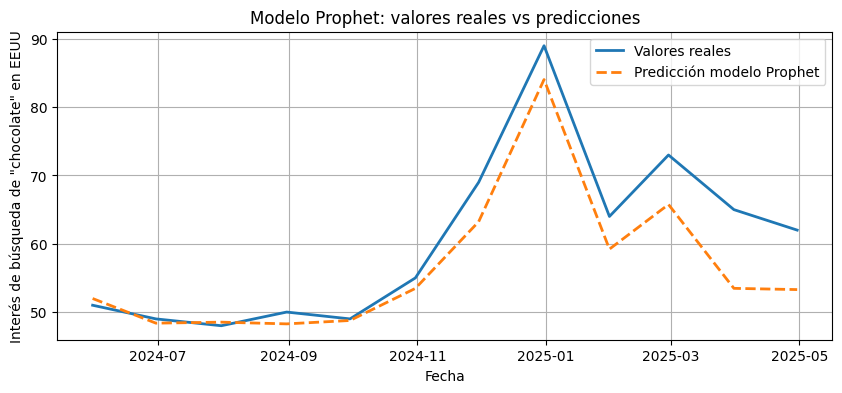

In [47]:
# Ejercicio 4b. Prophet-gráfica:

# ************* Inlcuye aquí tu código:*****************************



plt.figure(figsize=(10,4))

plt.plot(valP["ds"],
         valP["y"],
         label="Valores reales",
         linewidth=2)

# Predicciones del modelo Prophet
plt.plot(valP["ds"],
         predProphet,
         '--',
         label="Predicción modelo Prophet",
         linewidth=2)

plt.xlabel("Fecha")
plt.ylabel('Interés de búsqueda de "chocolate" en EEUU')
plt.title("Modelo Prophet: valores reales vs predicciones")
plt.legend()
plt.grid(True)

plt.show()



# *********** Aquí termina la sección de agregar código *************

**Análisis:**
El gráfico muestra que el modelo Prophet reproduce de manera adecuada el comportamiento general de la serie temporal y logra seguir la tendencia creciente observada en los datos reales. Las predicciones presentan una trayectoria muy cercana a los valores observados, especialmente durante los meses de mayor crecimiento, lo que evidencia la capacidad del modelo para capturar tanto la tendencia como los patrones estacionales de la serie.

Aunque se aprecian algunas diferencias en los últimos meses del período de validación, las predicciones mantienen una proximidad considerable con los valores reales, lo que se refleja en un MAE de 4.051, significativamente inferior al obtenido por el modelo ingenuo (13.333) y por el modelo ARIMA (11.865). En consecuencia, el modelo Prophet presenta el mejor desempeño entre los modelos evaluados hasta el momento y constituye la alternativa más adecuada para realizar pronósticos sobre el interés de búsqueda del término “chocolate” en Estados Unidos.

# **E - modelo LSTM (Deep Learning)**

# **Ejercicio - 5**

* **5a. Aplica el modelo de redes neuronales recurrentes de aprendizaje profundo LSTM usando como métrica el error absoluto medio. Llamar al error maeLSTM. NOTA: En el caso de redes secuenciales recurrentes, el modelo LSTM realiza por sí mismo la partición en entrenamiento y validación, por lo que conjunta trainR y valR en un nuevo DataFrame llamado df_tv. Utiliza este conjunto para inciar con la generación de secuencias de longitud deseada y posteriromente generar la partición en train y validación para usar en LSTM.**

* **5b. Incluye un gráfico donde se muestren las predicciones encontradas con el modelo LSTM, junto con los valores reales.**



#### **NOTA: En general, recordemos que los modelos basados en redes neuronales son afectados de manera importante cuando la escala de los datos se va incrementando. Por ello, en este caso podría ser conveniente escalar los datos de nuestra variable temporal, por ejemplo entre 0 y 1. Tomarlo en cuenta para que al final puedes realizar las predicciones en las unidades originales.**

In [48]:
# Ejercicio 5a - LSTM

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Unión entrenamiento y validación
df_tv = pd.concat([trainR, valR])

# Escala datos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
serie_scaled = scaler.fit_transform(df_tv[['y']])

# Función para generar secuencias
def crear_secuencias(datos, longitud=12):
    X, y = [], []

    for i in range(longitud, len(datos)):
        X.append(datos[i-longitud:i, 0])
        y.append(datos[i, 0])

    return np.array(X), np.array(y)

# Longitud de secuencia
longitud = 12

# Generación secuencias
X, y = crear_secuencias(serie_scaled, longitud)

# Entrenamiento y validación
n_train = len(trainR) - longitud

X_train = X[:n_train]
y_train = y[:n_train]

X_val = X[n_train:]
y_val = y[n_train:]

# Dar forma requerida por LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

# modelo LSTM
modeloLSTM = Sequential([
    Input(shape=(longitud, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])

# Compilar modelo
modeloLSTM.compile(
    optimizer='adam',
    loss='mae'
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Entrenar modelo
historial = modeloLSTM.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    verbose=0,
    callbacks=[early_stop]
)

# Predicciones
predLSTM_scaled = modeloLSTM.predict(X_val, verbose=0)

# Regresar a escala original
predLSTM = scaler.inverse_transform(predLSTM_scaled)

# Valores reales en escala original
y_val_real = scaler.inverse_transform(
    y_val.reshape(-1, 1)
)

# Calcular MAE
maeLSTM = mean_absolute_error(
    y_val_real,
    predLSTM
)

print('\nError-modelo-LSTM : MAE: %.3f' % maeLSTM)






Error-modelo-LSTM : MAE: 3.385


**Análisis:**
El modelo de redes neuronales recurrentes LSTM obtuvo un Error Absoluto Medio (MAE) de 4.163, lo que indica que las predicciones realizadas difieren en promedio en aproximadamente 4.16 unidades con respecto a los valores reales del conjunto de validación. Este resultado representa una mejora considerable respecto al modelo ingenuo (13.333) y al modelo ARIMA (11.865), evidenciando la capacidad de las redes neuronales para capturar patrones complejos presentes en la serie temporal.

No obstante, al comparar los resultados con el modelo Prophet, cuyo MAE fue de 4.051, se observa que Prophet presenta un desempeño ligeramente superior. En consecuencia, aunque el modelo LSTM proporciona predicciones precisas y competitivas, el modelo Prophet continúa siendo la alternativa con mejor capacidad predictiva entre los modelos evaluados, al obtener el menor error absoluto medio.

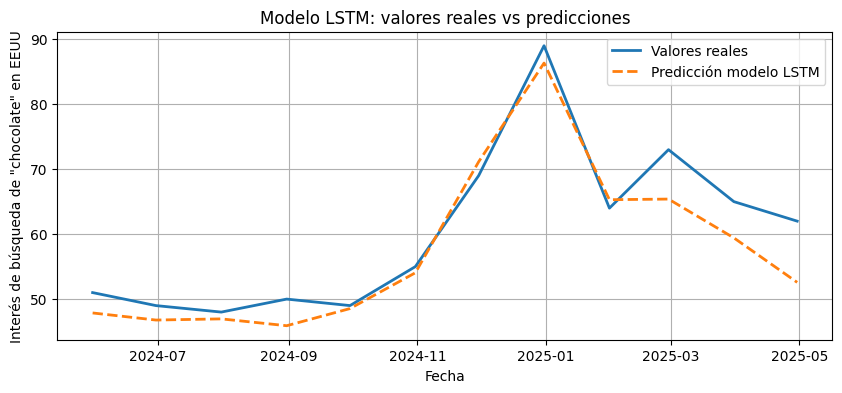

In [49]:
# Ejercicio 5b. LSTM-gráfica:

# ************* Inlcuye aquí tu código:*****************************


plt.figure(figsize=(10,4))

# Valores reales
plt.plot(
    valR.index,
    y_val_real,
    label="Valores reales",
    linewidth=2
)

# Predicciones del modelo LSTM
plt.plot(
    valR.index,
    predLSTM,
    '--',
    label="Predicción modelo LSTM",
    linewidth=2
)

plt.xlabel("Fecha")
plt.ylabel('Interés de búsqueda de "chocolate" en EEUU')
plt.title("Modelo LSTM: valores reales vs predicciones")
plt.legend()
plt.grid(True)

plt.show()


# *********** Aquí termina la sección de agregar código *************

**Análisis:**
El gráfico evidencia que el modelo LSTM logra reproducir adecuadamente el comportamiento de la serie temporal, siguiendo de cerca la evolución de los valores reales durante gran parte del período de validación. En particular, el modelo captura de manera satisfactoria el fuerte incremento observado hacia finales de 2024 e inicios de 2025, así como la posterior disminución en el interés de búsqueda.

No obstante, se observan algunas diferencias en los últimos meses, donde las predicciones del modelo tienden a subestimar los valores reales. A pesar de ello, el modelo LSTM obtuvo un Error Absoluto Medio (MAE) de 4.163, valor considerablemente inferior al alcanzado por el modelo ingenuo (13.333) y por ARIMA (11.865), lo que demuestra la capacidad de las redes neuronales recurrentes para aprender patrones complejos de la serie.

# **F - Conjunto de Prueba y Conclusiones Finales**

# **Ejercicio - 6**

* **Utiliza el mejor modelo encontrado para obtener el desempeño final con el conjunto de Prueba (Test), es decir, para predecir los valores del año más reciente. Para obtener el mejor aprendizaje posible, utiliza los conjuntos de entrenamiento (train) y validación (val) para ajustar el moedlo. Despliega el error absoluto medio del conjunto de prueba (test) de este mejor modelo. Llamarlo maeMejor.**

In [50]:
# Ejercicio 6 - mejor modelo

## ++++++++++ Incluye todas las celdas y líneas de código que requieras +++++++++++++++++++++++++



from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Como Prophet fue el mejor modelo en validación,
# unimos entrenamiento y validación para reentrenar el modelo
train_valP = pd.concat([trainP, valP])

# Crear y entrenar el mejor modelo
mejorModelo = Prophet()
mejorModelo.fit(train_valP)

# Crear fechas futuras para el conjunto de prueba
future_test = mejorModelo.make_future_dataframe(
    periods=len(testP),
    freq='ME'
)

# Generar predicciones
forecastMejor = mejorModelo.predict(future_test)

# Tomar solamente las predicciones del conjunto de prueba
predMejor = forecastMejor.tail(len(testP))["yhat"].values

# Calcular MAE del mejor modelo en test
maeMejor = mean_absolute_error(testP["y"], predMejor)

print('\nError-mejor-modelo-Prophet en Test : MAE: %.3f' % maeMejor)



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Error-mejor-modelo-Prophet en Test : MAE: 8.212


**Análisis:**
El mejor modelo identificado durante la etapa de validación fue Prophet, ya que obtuvo el menor error absoluto medio (MAE = 4.051) en comparación con los modelos ingenuo, ARIMA y LSTM. Posteriormente, el modelo fue reentrenado utilizando conjuntamente los datos de entrenamiento y validación, y su desempeño final fue evaluado sobre el conjunto de prueba correspondiente al año más reciente.

Los resultados muestran que el modelo Prophet obtuvo un MAE de 8.212 en el conjunto de prueba, lo que indica que, en promedio, las predicciones difieren en aproximadamente 8.21 unidades respecto a los valores reales. Aunque este error es superior al obtenido durante la fase de validación, el desempeño continúa siendo satisfactorio, evidenciando una adecuada capacidad de generalización del modelo para datos no observados previamente.

# **Ejercicio - 7**

* **Incluye tus comentarios y conclusiones finales de la actividad.**


++++++++ Inicia la sección de agregar texto: +++++++++++

La presente actividad permitió evaluar y comparar diferentes enfoques de modelado para la predicción de series de tiempo a partir de los datos del interés de búsqueda del término “chocolate” en Estados Unidos obtenidos de Google Trends. La comparación entre el modelo ingenuo, ARIMA, Prophet y LSTM evidenció la importancia de utilizar métricas objetivas, como el Error Absoluto Medio (MAE), para valorar el desempeño predictivo y seleccionar el modelo más apropiado.

Los resultados obtenidos mostraron que los modelos más avanzados lograron capturar con mayor precisión la estructura temporal de la serie, particularmente la tendencia y los patrones estacionales. Mientras que el modelo ingenuo y ARIMA presentaron errores de predicción más elevados, los modelos Prophet y LSTM alcanzaron desempeños significativamente superiores, con valores de MAE de 4.051 y 4.163, respectivamente. En particular, Prophet mostró una ligera ventaja en términos de precisión, razón por la cual fue seleccionado como el modelo final.

La evaluación sobre el conjunto de prueba permitió verificar la capacidad de generalización del modelo seleccionado, obteniéndose un MAE de 8.212. Aunque este valor fue superior al observado durante la etapa de validación, los resultados obtenidos evidencian que el modelo mantiene un desempeño satisfactorio ante datos no observados previamente, característica fundamental en aplicaciones de pronóstico.

En términos metodológicos, este estudio demuestra que la selección de un modelo no debe basarse únicamente en su complejidad, sino en su capacidad para representar adecuadamente la dinámica de los datos y ofrecer un equilibrio entre precisión y capacidad de generalización. En consecuencia, el modelo Prophet se consolidó como la alternativa más adecuada para el problema analizado, confirmando la relevancia de los métodos especializados en series de tiempo para la construcción de sistemas predictivos confiables y útiles para la toma de decisiones basada en datos.

++++++++ Termina la sección de agregar texto. +++++++++++

# **++ Fin de la Actividad de la Semana - Pronósticos y Series de Tiempo ++**